In [41]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], dtype=float)
y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3], dtype=float)





In [42]:
# A1
import numpy as np
import matplotlib.pyplot as plt

# Thomas Algorithm
def thomas_algorithm(a, b, c, d):
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x


#get the second derivatives
def getM(x, y):
    n = len(x)
    h = np.diff(x)

    A = np.zeros(n-2)
    B = np.zeros(n-2)
    C = np.zeros(n-2)
    D = np.zeros(n-2)

    for i in range(1, n-1):
        A[i-1] = h[i-1]
        B[i-1] = 2*(h[i-1] + h[i])
        C[i-1] = h[i]
        D[i-1] = 6*((y[i+1]-y[i])/h[i] - (y[i]-y[i-1])/h[i-1])

    M_inner = thomas_algorithm(A, B, C, D)
    M = np.concatenate(([0], M_inner, [0])) 

    return M


# the spline at 1 x 
def spline_eval(x, y, M, xval):
    i = np.searchsorted(x, xval) - 1
    i = np.clip(i, 0, len(x)-2)

    h = x[i+1] - x[i]

    term1 = (M[i]/(6*h)) * (x[i+1]-xval)**3
    term2 = (M[i+1]/(6*h)) * (xval-x[i])**3
    term3 = (y[i]/h - (M[i]*h)/6) * (x[i+1]-xval)
    term4 = (y[i+1]/h - (M[i+1]*h)/6) * (xval-x[i])

    return term1 + term2 + term3 + term4


M = getM(x, y)

"""
Since there are 20 data points, the amount of unknowns is 18 .
The system is a 18 x 18 tridiagonal system.
The continuity conditions at each interior knot are 
continuity of the function, the first derivative, and the second derivative.
The boundary conditions are that the second derivative at the endpoints will be zero.
"""

'\nSince there are 20 data points, the amount of unknowns is 18 .\nThe system is a 18 x 18 tridiagonal system.\nThe continuity conditions at each interior knot are \ncontinuity of the function, the first derivative, and the second derivative.\nThe boundary conditions are that the second derivative at the endpoints will be zero.\n'

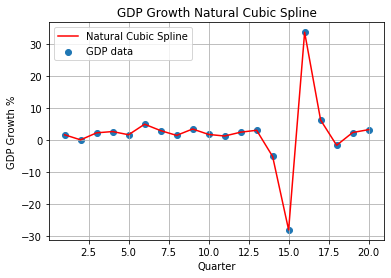

'\nDue to the method of evaluation, the graph is continious, so it looks visually smooth. \nThe spike about the Covid data makes sense, and is economically realistic. \nThis seems reasonable as it is visually smooth, and accounts for the Covid data. \n'

In [43]:
#A2
#plot
x_full = np.arange(1, 21)
y_full_spline = np.zeros(len(x_full))

for i in range(len(x_full)):
    y_full_spline[i] = spline_eval(x, y, M, x_full[i])

plt.scatter(x, y, label="GDP data")
plt.plot(x_full, y_full_spline, label="Natural Cubic Spline", color='red')
plt.xlabel("Quarter")
plt.ylabel("GDP Growth %")
plt.title("GDP Growth Natural Cubic Spline")
plt.legend()
plt.grid()
plt.show()

"""
Due to the method of evaluation, the graph is continious, so it looks visually smooth. 
The spike about the Covid data makes sense, and is economically realistic. 
This seems reasonable as it is visually smooth, and accounts for the Covid data. 
"""

In [12]:
#A3
"""

According to lecture 14 Runge's phenomenon is when high degree polynomials oscillate wildly at the edges of the data range. 
Polynomial fitting to the degree n-1 will overfit and oscillate. 
Exact interpolation means the curve passes through every data point exactly. 
The trade off while prioritizing this is while the fit at the points is perfect, outliers can cause unrealistic graphs. 
Numerical stability is the property of a algorithm that makes sure that erorrs don't propogate and balloon out. 
If Numerical stability is prioritized, the graph will make more sense, but it will be less accurate. 
Smoothing splines or weighted least squares would be preferable as it would minimize the effect of the Covid data. 

"""

'\nRunge phenomenon is the tendency of a global interpolating polynomial, especially high-degree, to oscillate badly, especially near the ends of the interval. The polynomial fitting lecture explicitly warns that degree \n𝑛\n−\n1\nn−1 interpolation “will almost always overfit and oscillate,” and the data interpolation lecture says high-degree polynomials can oscillate wildly at the edges.\n\nA cubic spline reduces that problem because it is piecewise local rather than one global high-degree polynomial. That is why splines are usually smoother and more stable than global interpolation. But the trade-off is that an exact spline still must pass through an outlier like 2020 Q2 = −28.1, so it can create unrealistic local swings nearby. The spline lecture says cubic splines “balance flexibility and smoothness without the oscillations of high-degree polynomial interpolation,” but the midterm also asks you to think about outlier sensitivity.\n\nSo for this dataset, smoothing splines or weighte

B1:
Degree 4 MSE = 99.30773796212381
Degree 4 R^2 = 0.016632392138783647
Condition number of V = 482958.7228354322


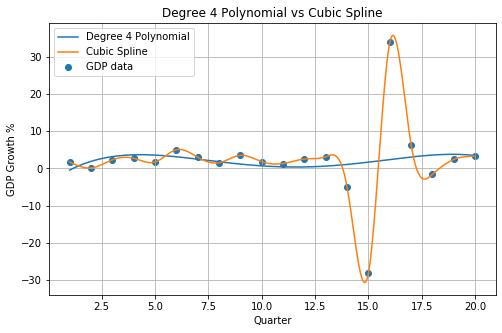

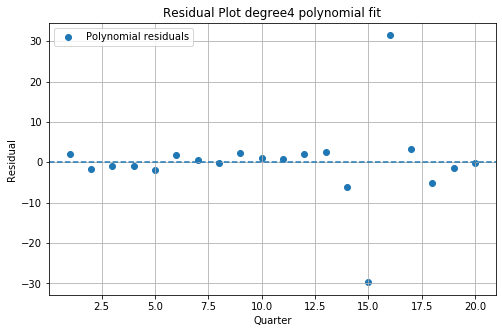

In [52]:
#B1
# errors tools calculated
def mse(y, y_p):
    return np.mean((y - y_p)**2)

def r_sq(y, y_p):
    ss_tot = np.sum((y - np.mean(y))**2)
    ss_res = np.sum((y - y_p)**2)
    return 1 - ss_res/ss_tot

x_plot = np.linspace(x.min(), x.max())
# vandermonde matrix
def vandermonde_matrix(x, degree):
    n = len(x)
    V = np.zeros((n, degree + 1))
    for i in range(n):
        for j in range(degree + 1):
            V[i, j] = x[i]**(degree - j)
    return V

#least square
def custom_ls(x, y):
    n = len(x)
    sx = np.sum(x)
    sy = np.sum(y)
    sxx = np.sum(x * x)
    sxy = np.sum(x * y)

    m = (n * sxy - sx * sy) / (n * sxx - sx * sx)
    b = (sy / n) - m * (sx / n)

    return m, b


degree = 4
V = vandermonde_matrix(x, degree)

#normal equations
coef = np.linalg.solve(V.T @ V, V.T @ y)

Y_poly = V @ coef
x_plot = np.linspace(x.min(), x.max(), 400)
Vp = vandermonde_matrix(x_plot, degree)
y_plot = Vp @ coef

# spline comparition
y_spline_plot = np.zeros(len(x_plot))
for i in range(len(x_plot)):
    y_spline_plot[i] = spline_eval(x, y, M, x_plot[i])

print("B1:")
print("Degree 4 MSE =", mse(y, Y_poly))
print("Degree 4 R^2 =", r_sq(y, Y_poly))
print("Condition number of V =", np.linalg.cond(V))

plt.figure(figsize=(8,5))
plt.scatter(x, y, label="GDP data")
plt.plot(x_plot, y_plot, label="Degree 4 Polynomial")
plt.plot(x_plot, y_spline_plot, label="Cubic Spline")
plt.xlabel("Quarter")
plt.ylabel("GDP Growth %")
plt.title("Degree 4 Polynomial vs Cubic Spline")
plt.legend()
plt.grid()
plt.show()

# Residual plot required by midterm
poly_residuals = y - Y_poly

plt.figure(figsize=(8,5))
plt.scatter(x, poly_residuals, label="Polynomial residuals")
plt.axhline(0, linestyle='--')
plt.xlabel("Quarter")
plt.ylabel("Residual")
plt.title("Residual Plot degree4 polynomial fit")
plt.legend()
plt.grid()
plt.show()

"""
The degree 4 Polynomial gives a better idea of what the trend actually is. 
The cubic spline is better at reproducing specific data points. 
The trade off is a more accurate trend vs more accurate specific data points. 

"""

Slope: -0.0173364485981308
Intercept: 2.3041121495327097


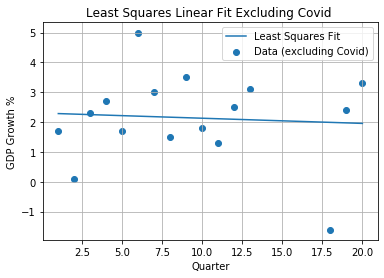

"\nI got that the slope was -0.0173364485981308. \nLinear doesn't work well because ther is not much of a corelarion between the line\nand the data, a oscillating trend makes more sense. \nA linear model requires the assumption that the data is stable and linear when removing the covid data. \n"

In [58]:
# B2
#lest squares

def custom_ls(x, y):
    n = len(x)
    sx = np.sum(x)
    sy = np.sum(y)
    sxx = np.sum(x*x)
    sxy = np.sum(x*y)

    m = (n*sxy - sx*sy) / (n*sxx - sx*sx)
    b = (sy/n) - m*(sx/n)

    return m, b

# excluding the covid data
mask = np.array([True, True, True, True, True,
                 True, True, True, True, True,
                 True, True, True, False, False,
                 False, False, True, True, True])

x_no_covid = x[mask]
y_no_covid = y[mask]

m, b = custom_ls(x_no_covid, y_no_covid)

res = y_no_covid - (m*x_no_covid + b)
print("Slope:", m)
print("Intercept:", b)

plt.scatter(x_no_covid, y_no_covid, label="Data (excluding Covid)")
plt.plot(x_no_covid, m*x_no_covid + b, label="Least Squares Fit")
plt.xlabel("Quarter")
plt.ylabel("GDP Growth %")
plt.title("Least Squares Linear Fit Excluding Covid ")
plt.legend()
plt.grid()
plt.show()


"""
I got that the slope was -0.0173364485981308. 
Linear doesn't work well because ther is not much of a corelarion between the line
and the data, a oscillating trend makes more sense. 
A linear model requires the assumption that the data is stable and linear when removing the covid data. 
"""

In [59]:
#C1

"""
For a policy maker I'd recomend the cubic spline method, due to its accuracy and estimations in between, with one caveat- to exclude the covid data. 
The drawback of the sensitivity of the cubic spline method would be counteracted by the removal of the outlier covid data. 
The spline is more smooth and accurate, and preserves the continuity of the funtion up till the second derivative. 
"""

#C added
"""
Big O describes how runtime increases as input size (n) increases. The least squares model would be O(n) because
it goes through the data once . The degree-4 polynomial fit is also O(n) becasuse the degree is fixed. The natural 
cubic spline method is also O(n) because constructing the tridiagonal system is linear, and solving the thomas algorythm is also linear. 
The Big O doesnt change throughout these methods, so it wouldn't change my recomendation. 
"""

"\nBig O describes how runtime increases as input size (n) increases. The least squares model would be O(n) because\nit goes through the data once . The degree-4 polynomial fit is also O(n) becasuse the degree is fixed. The natural \ncubic spline method is also O(n) because constructing the tridiagonal system is linear, and solving the thomas algorythm is also linear. \nThe Big O doesnt change throughout these methods, so it wouldn't change my recomendation. \n"